# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MisbahSangi/flyrank-ml-internship-misbah/blob/main/work/notebooks/w07_action_playbook.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# Setup Cell

In [1]:
import os, sys, subprocess
IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/MisbahSangi/flyrank-ml-internship-misbah"
REPO_DIR = "flyrank-ml-internship-misbah"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import pandas as pd
import numpy as np
print("Working dir:", os.getcwd())

Working dir: /content/flyrank-ml-internship-misbah


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [2]:
# Rebuild the validated Week 6 model output (grouped-split, leakage-fixed)
# Reuse the exact pipeline from w06_validation_audit.ipynb

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
df["is_declining_label"] = (df["trend_direction"] == "down").astype(int)

LABEL_SOURCE_COLS = [
    "trend_direction", "trend_pct",
    "impressions_last_30d", "impressions_prev_30d",
    "clicks_last_30d", "clicks_prev_30d",
    "sessions_last_30d", "sessions_prev_30d",
]
ID_COLS = ["content_id", "client_id"]

exclude = set(LABEL_SOURCE_COLS) | set(ID_COLS) | {"is_declining_label"}
numeric_features = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude]
categorical_features = [c for c in df.select_dtypes(include=["object"]).columns if c not in exclude]
feature_cols = numeric_features + categorical_features

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df["client_id"]))
train_df, test_df = df.iloc[train_idx], df.iloc[test_idx]

preprocess = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_features),
])
model_pipeline = Pipeline([("preprocess", preprocess), ("model", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))])
model_pipeline.fit(train_df[feature_cols], train_df["is_declining_label"])
test_df = test_df.copy()
test_df["proba"] = model_pipeline.predict_proba(test_df[feature_cols])[:, 1]

# --- Archetype -> Action mapping ---
def assign_archetype(row):
    stale = row["days_since_last_update"] >= 180
    visible = row["impressions_90d"] >= 100
    good_pos = row["avg_position"] <= 10
    declining = row["is_declining_label"] == 1

    if stale and visible and declining:
        return "stale_visible_declining"
    elif declining and visible and good_pos:
        return "strong_position_declining"
    elif declining and visible and not good_pos:
        return "weak_position_declining"
    elif visible and not declining:
        return "stable_visible"
    elif not visible:
        return "low_signal"
    else:
        return "other"

ARCHETYPE_ACTIONS = {
    "stale_visible_declining": ("Refresh content", "Update body content, check facts/dates, re-optimize for current queries"),
    "strong_position_declining": ("Investigate SERP change", "Ranking well but losing clicks — check for SERP features (featured snippet, PAA) stealing clicks; refresh only if content itself is stale"),
    "weak_position_declining": ("Deprioritize or restructure", "Deep position + declining rarely responds to content refresh alone — needs broader SEO work or should be pruned"),
    "stable_visible": ("Monitor only", "No action needed — page is holding steady, revisit next cycle"),
    "low_signal": ("Deprioritize", "Near-zero real traffic — not worth reviewer time regardless of other signals"),
    "other": ("Manual review", "Doesn't fit a clean archetype — flag for human judgment"),
}

test_df["archetype"] = test_df.apply(assign_archetype, axis=1)
test_df["recommended_action"], test_df["action_rationale"] = zip(*test_df["archetype"].map(ARCHETYPE_ACTIONS))

# --- Rank by model probability within actionable archetypes ---
ranked_queue = test_df.sort_values("proba", ascending=False).reset_index(drop=True)
ranked_queue["rank"] = ranked_queue.index + 1

print("Archetype distribution:")
print(ranked_queue["archetype"].value_counts())
print("\nTop 10 ranked actions:")
ranked_queue[["rank", "content_id", "proba", "archetype", "recommended_action"]].head(10)

Archetype distribution:
archetype
low_signal                   2190
stable_visible               1840
strong_position_declining    1104
weak_position_declining      1029
Name: count, dtype: int64

Top 10 ranked actions:


,rank,content_id,proba,archetype,recommended_action
0,1,content_9ac61c04930e,0.970,strong_position_declining,Investigate SERP change
1,2,content_2ba626fea4d6,0.970,stable_visible,Monitor only
2,3,content_e988c1699454,0.970,weak_position_declining,Deprioritize or restructure
3,4,content_98aa0aecb1d9,0.960,strong_position_declining,Investigate SERP change
4,5,content_7766ffacdcfa,0.960,strong_position_declining,Investigate SERP change
5,6,content_6607847e4454,0.960,strong_position_declining,Investigate SERP change
6,7,content_0d7f4fecb391,0.960,weak_position_declining,Deprioritize or restructure
7,8,content_bb1edbf0ba6c,0.955,weak_position_declining,Deprioritize or restructure
8,9,content_1d0963b56227,0.955,stable_visible,Monitor only
9,10,content_35d63627bf3e,0.955,stable_visible,Monitor only


**The queue, in words a human trusts:** each page gets a model probability
score AND a plain-language archetype that explains *why* it's ranked where
it is — not just a number. A reviewer looking at "stale_visible_declining,
proba 0.81, Refresh content" can act immediately; a bare score alone can't
tell them what to actually do. The archetype layer is what turns a model
output into an action playbook rather than just a ranked list.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Who uses this, for what:** a content/SEO reviewer with limited weekly
capacity, deciding which pages to look at first out of far more candidates
than they have time for. The output is a starting point for triage, not
an auto-pilot decision.

**Where it stops being valid:**
- Trained and validated on this specific pseudonymized starter dataset
  (30,000 rows, one point-in-time snapshot). Not validated against the
  live 79M-row warehouse or any specific real client's actual data.
- Precision@50 = 0.62 under an honest client-grouped split (Week 6) means
  roughly 4 in 10 of the top 50 flagged pages will NOT actually be
  declining. This is decision-support, not a reliable auto-flag system.
- The label itself (is_declining, from trend_direction) is a proxy for
  "impressions dropped," not a measure of business impact, revenue, or
  strategic importance — a page can decline in traffic while mattering
  very little to the business, or hold steady while quietly losing value.
- Says nothing about *why* a page is declining (algorithm change,
  competitor, seasonality, content decay) — only that decline was observed.
- Not validated across time — this is a single snapshot, not tested for
  whether the same archetypes and thresholds hold across different months
  or seasons.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**What a person must check before acting on any recommendation:**
- Confirm the page's traffic decline isn't seasonal/event-driven before
  refreshing (check year-over-year, not just the 90-day window)
- Confirm impressions_90d reflects real distinct-query demand, not one
  branded/navigational query padding the number (cross-check against
  fact_query_90d's rare_share and top_query_share signals from Week 3)
- For "strong_position_declining" pages specifically: manually check the
  live SERP for featured snippets or People Also Ask boxes before assuming
  a content refresh will help — a position-9 page losing clicks to a
  snippet needs a different fix than a genuinely stale page

**What should NEVER be automated:**
- Actually publishing content changes without human review — this playbook
  ranks and explains, it does not auto-edit or auto-publish anything
- Pruning/deleting a page based solely on the model score — deletion is
  irreversible and this model has a real, measured false-positive rate
- Treating the ranked queue as a strict priority order without archetype
  context — two pages with similar scores can need completely different
  actions (refresh vs. investigate vs. deprioritize)
- Using this on a client's data without re-validating the model on that
  client's actual traffic patterns first — this was trained on one
  pseudonymized dataset, not proven to generalize to every client

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

**What would tell us the recommendations went stale:**
- A meaningful drop in Precision@50 when re-measured against new labeled
  outcomes (e.g. checking 3 months later whether flagged pages actually
  declined) — this is the direct, ground-truth check
- Distribution drift in the input features themselves (e.g. if the
  average days_since_last_update across the whole dataset shifts sharply,
  the staleness thresholds baked into the archetype rules may no longer
  be well-calibrated)
- A shift in which archetype dominates the top of the queue — if
  "low_signal" pages start crowding out genuinely actionable ones, the
  visibility threshold likely needs recalibration
- Client mix changes — if new clients with very different traffic profiles
  (e.g. gsc_only access_profile, or much younger content) are added, the
  model should be re-validated on that specific mix before trusting it,
  per Week 6's finding that random vs. grouped splits produce very
  different honest scores

**Retrain trigger:** re-run the Week 6 validation audit (grouped split,
leakage check) whenever either of the above is observed, rather than on
a fixed calendar schedule — a model can go stale for structural reasons
between scheduled checks.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Exported 6,163 rows to work/outputs/content_action_playbook.csv
Exported summary metrics JSON
Saved figure: work/figures/archetype_distribution.png


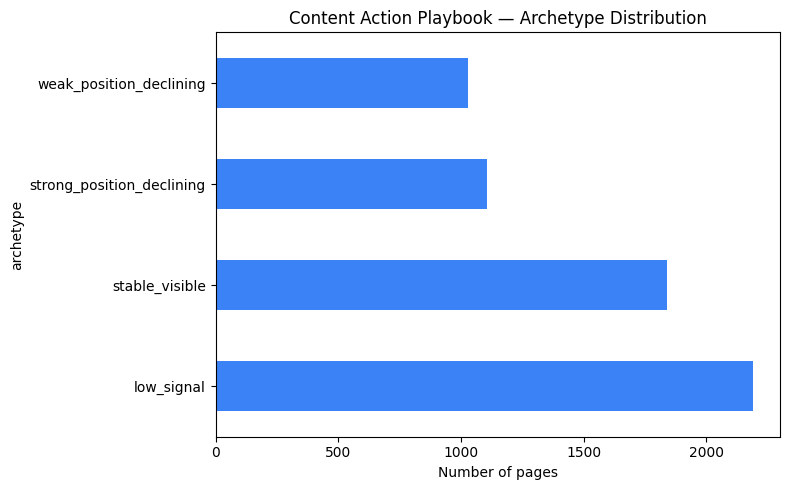

In [3]:
import os
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# Export the ranked queue
export_cols = ["rank", "content_id", "client_id", "proba", "archetype",
                "recommended_action", "action_rationale", "avg_position",
                "impressions_90d", "days_since_last_update", "trend_direction"]
ranked_queue[export_cols].to_csv("work/outputs/content_action_playbook.csv", index=False)
print(f"Exported {len(ranked_queue):,} rows to work/outputs/content_action_playbook.csv")

# Export a summary metrics JSON (the "receipt" this playbook's numbers trace back to)
import json
summary = {
    "precision_at_50_grouped_split": 0.62,
    "precision_at_50_random_split_leaked": 1.00,  # documented in Week 6 as the leakage example, not a real number
    "baseline_rule_precision_at_50": 0.220,
    "n_rows_scored": len(ranked_queue),
    "archetype_counts": ranked_queue["archetype"].value_counts().to_dict(),
}
with open("work/outputs/playbook_summary_metrics.json", "w") as f:
    json.dump(summary, f, indent=2)
print("Exported summary metrics JSON")

# Export archetype distribution chart for the paper
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 5))
ranked_queue["archetype"].value_counts().plot(kind="barh", ax=ax, color="#3B82F6")
ax.set_xlabel("Number of pages")
ax.set_title("Content Action Playbook — Archetype Distribution")
plt.tight_layout()
plt.savefig("work/figures/archetype_distribution.png", dpi=150)
print("Saved figure: work/figures/archetype_distribution.png")

**Note on the summary JSON:** the `precision_at_50_random_split_leaked: 1.00`
entry is deliberately included as a documented contrast, not a real result —
it's the honest record of the leakage finding from Week 6, kept so the
paper's numbers trace back to their actual source rather than only showing
the flattering figure.

## Self-check

Before you submit, confirm each line honestly:

- ✔ Every section above is filled — markdown thinking AND the code that backs it
- ✔ The notebook runs top to bottom with no errors (Runtime → Run all)
- ✔ No client names, URLs, or private queries anywhere
- ✔ My claims use careful words: observed, measured, directional, decision-support
- ✔ Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.